# Essential Libraries for File and Image Processing in Driver Alertness Evaluation

In [9]:
import os
import zipfile
import cv2
import shutil
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import pickle
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import os
from tqdm import tqdm
from mtcnn import MTCNN
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
print("TensorFlow version:", tf.__version__)
detector = MTCNN()
from PIL import Image
from tensorflow.keras.applications import VGG16, VGG19, Xception, InceptionV3, EfficientNetB0
import numpy as np
import tensorflow as tf
import os 
from sklearn.model_selection import train_test_split
# from google.colab import drive
from tensorflow.keras.applications.vgg16 import preprocess_input


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


TensorFlow version: 2.20.0


# Dynamic Video Frame Extraction and Categorization for Driver Alertness Detection

In [ ]:


# Define the root directory where the "Data" folder exists
root_dir = r'C:\tausif\Data'  # Update with your path

# Create Preprocessed directory to store the extracted frames
preprocessed_dir = os.path.join(root_dir, 'Preprocessed')
if not os.path.exists(preprocessed_dir):
    os.makedirs(preprocessed_dir)

# Define subfolders for Alert, Low, and Drowsy states
alert_dir = os.path.join(preprocessed_dir, 'Alert')
low_dir = os.path.join(preprocessed_dir, 'Low')
drowsy_dir = os.path.join(preprocessed_dir, 'Drowsy')

# Create the folders if they do not exist
for folder in [alert_dir, low_dir, drowsy_dir]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Function to extract frames from a video and save them to a specific folder
def extract_frames(video_path, output_folder, start_frame=0, fps=30, fold_part="", subfolder=""):
    # Load video
    video = cv2.VideoCapture(video_path)
    frame_num = start_frame
    video_fps = video.get(cv2.CAP_PROP_FPS)  # Get the FPS of the video
    print(f"  FPS of video: {video_fps}")

    # Read frames and save them as images
    while True:
        ret, frame = video.read()
        if not ret:
            break

        # Check if the current frame should be saved (one frame per second)
        if frame_num % round(video_fps) == 0:
            # Create a descriptive filename including folder and subfolder names
            frame_filename = os.path.join(output_folder, f"frame_{fold_part}_{subfolder}_{frame_num}.jpg")
            
            # Always save the frame, even if it already exists (overwrite)
            cv2.imwrite(frame_filename, frame)
            print(f"  Saved frame {frame_num} from {video_path} to {output_folder}")

        frame_num += 1

    video.release()

# Traverse the Data folder structure and process videos
for fold_part in os.listdir(root_dir):
    fold_part_path = os.path.join(root_dir, fold_part)
    
    # Check if the folder is of the type Fold1_part1, Fold1_part2, ..., Fold5_part2
    if os.path.isdir(fold_part_path) and fold_part.startswith('Fold'):
        print(f"Processing folder: {fold_part_path}")
        for subfolder in os.listdir(fold_part_path):
            subfolder_path = os.path.join(fold_part_path, subfolder)
            
            if os.path.isdir(subfolder_path):
                print(f"  Processing subfolder: {subfolder_path}")
                # Loop through the 3 videos (0.mov, 5.mov, 10.mov)
                for video_name in ['0.mov', '5.mov', '10.mov']:
                    video_path = os.path.join(subfolder_path, video_name)
                    
                    if os.path.exists(video_path):
                        print(f"    Found {video_name} in {subfolder_path}")
                        # Determine the target folder based on the video name
                        if video_name == '0.mov':
                            target_folder = alert_dir
                        elif video_name == '5.mov':
                            target_folder = low_dir
                        elif video_name == '10.mov':
                            target_folder = drowsy_dir

                        # Get the last saved frame in the target folder
                        existing_frames = [f for f in os.listdir(target_folder) if f.startswith(f"frame_")]
                        existing_frames.sort()  # Sort the frames by name (numerical order)

                        # If frames exist, determine the last saved frame number
                        if existing_frames:
                            last_saved_frame = int(existing_frames[-1].split('_')[3].split('.')[0])  # Extract frame number
                            print(f"    Found {last_saved_frame} frames in {target_folder}, starting from frame {last_saved_frame + 1}")
                        else:
                            last_saved_frame = 0
                            print(f"    No frames found in {target_folder}, starting from frame 1")

                        # Extract frames and save them to the corresponding folder starting from the last processed frame
                        extract_frames(video_path, target_folder, start_frame=last_saved_frame + 1, fold_part=fold_part, subfolder=subfolder)

print("Video frames have been extracted and saved.")

# Mounting Google Drive for Seamless Data Access and Storage

In [ ]:
drive.mount('/content/drive')

# Setting Up Base Directory for Preprocessed Data Storage

In [ ]:
base_path = r"C:\tausif\Data\Preprocessed"  

In [8]:
# ----------------------------------------------------------
# Define base dataset directory
# This is the folder that contains one or more datasets
# ----------------------------------------------------------

# import os

# base_path = "/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data"

# if not os.path.exists(base_path):
#     raise ValueError(f"Base path not found: {base_path}")

# print("Base path verified.")

# Detecting and Listing Available Datasets for Processing

In [4]:
# ----------------------------------------------------------
# Detect all dataset folders inside base directory
# ----------------------------------------------------------

datasets = [
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
]

if len(datasets) == 0:
    raise ValueError("No dataset folders found.")

print("Available datasets:")
for i, d in enumerate(datasets):
    print(f"{i} → {d}")

Available datasets:
0 → Drowsy
1 → Non-Drowsy


# Interactive Dataset Selection for Targeted Analysis

In [ ]:
# ----------------------------------------------------------
# Select dataset by index
# ----------------------------------------------------------

dataset_index = int(input("Enter dataset index to use: "))

if dataset_index < 0 or dataset_index >= len(datasets):
    raise ValueError("Invalid dataset index.")

selected_dataset = datasets[dataset_index]
data_path = os.path.join(base_path, selected_dataset)

print("Selected dataset:", selected_dataset)
print("Dataset path:", data_path)

# Automating Dataset Structuring and Image Count Verification

In [ ]:
dataset_folder = base_path
non_drowsy_path = os.path.join(dataset_folder, "Non-Drowsy")
drowsy_path     = os.path.join(dataset_folder, "Drowsy")

# If your original folder names are different, map them:
original_active  = os.path.join(dataset_folder, "Active Subjects")
original_fatigue = os.path.join(dataset_folder, "Fatigue Subjects")

# Automatically map if needed
if os.path.exists(original_active) and not os.path.exists(non_drowsy_path):
    os.rename(original_active, non_drowsy_path)

if os.path.exists(original_fatigue) and not os.path.exists(drowsy_path):
    os.rename(original_fatigue, drowsy_path)


# ----------------------------------------------------------
# Verify dataset structure
# ----------------------------------------------------------

if os.path.exists(non_drowsy_path) and os.path.exists(drowsy_path):
    print("Dataset structure verified ✅ (Drowsy / Non-Drowsy)")
else:
    print("Dataset structure missing ❌")


# ----------------------------------------------------------
# Count images per class
# ----------------------------------------------------------

def count_images(folder_path):
    return len([
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

non_drowsy_count = count_images(non_drowsy_path)
drowsy_count     = count_images(drowsy_path)

print(f"Non-Drowsy images: {non_drowsy_count}")
print(f"Drowsy images: {drowsy_count}")
print(f"Total images: {non_drowsy_count + drowsy_count}")

Dataset structure verified ✅ (Drowsy / Non-Drowsy)
Non-Drowsy images: 15389
Drowsy images: 19416
Total images: 34805


# Validating and Detecting Relevant Class Folders for Dataset Integrity

In [7]:
# ----------------------------------------------------------
# Detect valid class folders only
# Excludes system folders like __MACOSX
# ----------------------------------------------------------

classes = []

for folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, folder)

    # Condition 1: Must be directory
    if not os.path.isdir(folder_path):
        continue

    # Condition 2: Ignore hidden/system folders
    if folder.startswith("_") or folder.startswith("."):
        continue

    # Condition 3: Must contain at least 1 image
    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(image_files) > 0:
        classes.append(folder)

print("Valid detected classes:")
for c in classes:
    print("-", c)

Valid detected classes:
- Drowsy
- Non-Drowsy


# Count number of images per class

In [8]:
# ----------------------------------------------------------
# Count number of images per class
# ----------------------------------------------------------

for class_name in classes:
    class_path = os.path.join(base_path, class_name)
    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    print(f"{class_name}: {image_count} images")

Drowsy: 19416 images
Non-Drowsy: 15389 images


# Visualize random samples from each class

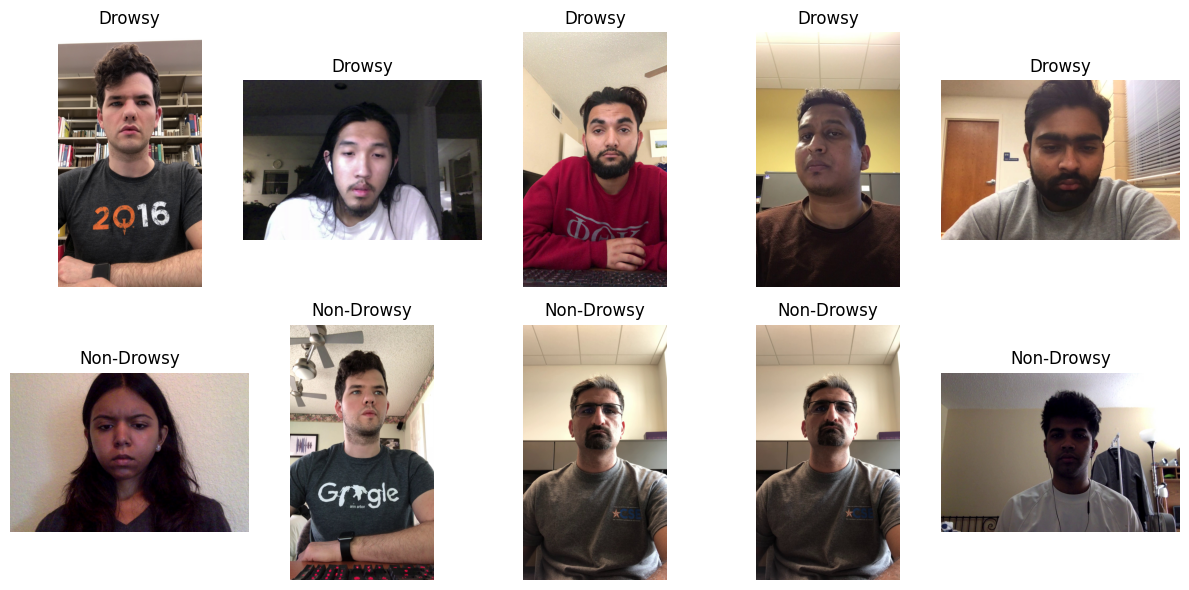

In [ ]:
# ----------------------------------------------------------
# Visualize random samples from each class
# ----------------------------------------------------------



samples_per_class = 5  # number of images to show per class

plt.figure(figsize=(12, 6))

plot_index = 1

for class_name in classes:

    class_path = os.path.join(base_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_samples = random.sample(image_files, samples_per_class)

    for file in random_samples:
        file_path = os.path.join(class_path, file)

        img = Image.open(file_path)

        plt.subplot(len(classes), samples_per_class, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

# Efficient Dataset Integrity Check: Identifying Corrupted Images

In [ ]:
# ----------------------------------------------------------
# Fast integrity check: 100 random images per class
# ----------------------------------------------------------
corrupted_images = []
sample_size = 10

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Random sample (safe even if less than 10 images)
    sampled_files = random.sample(image_files, min(sample_size, len(image_files)))

    for file in sampled_files:
        file_path = os.path.join(class_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            corrupted_images.append(file_path)

print("Total images checked:", sample_size * len(classes))
print("Corrupted images found:", len(corrupted_images))

Total images checked: 20
Corrupted images found: 0


# Image Size Distribution Analysis and Visualization

Number of unique image resolutions: 6


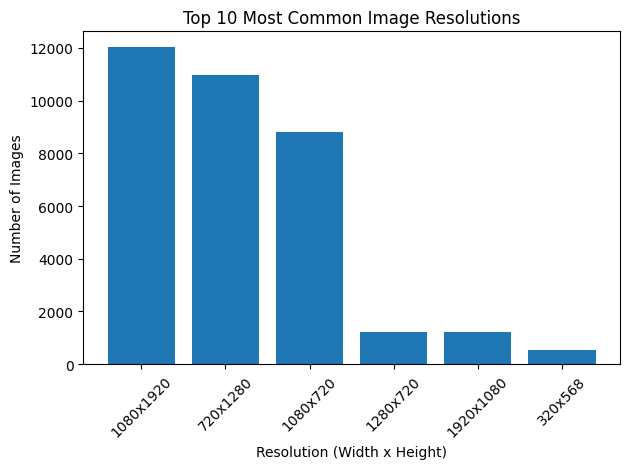

In [16]:
# ----------------------------------------------------------
# Analyze image size distribution (with visualization)
# ----------------------------------------------------------

from PIL import Image
from collections import Counter
import os
import matplotlib.pyplot as plt

image_sizes = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            file_path = os.path.join(class_path, file)

            with Image.open(file_path) as img:
                image_sizes.append(img.size)  # (width, height)

# Count unique resolutions
size_counts = Counter(image_sizes)

print("Number of unique image resolutions:", len(size_counts))

# ----------------------------------------------------------
# 1️ Bar Chart – Top 10 Most Common Resolutions
# ----------------------------------------------------------

top_sizes = size_counts.most_common(10)

sizes = [f"{w}x{h}" for (w, h), _ in top_sizes]
counts = [count for _, count in top_sizes]

plt.figure()
plt.bar(sizes, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Common Image Resolutions")
plt.xlabel("Resolution (Width x Height)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()



# Face Detection and Cropping for Image Preprocessing

In [11]:
# Function to detect and crop face few images
def detect_and_crop_face(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) > 0:
        x, y, w, h = results[0]['box']

        # Ensure bounding box is valid
        x, y = max(0, x), max(0, y)

        face = img_rgb[y:y+h, x:x+w]
        return face
    else:
        return None

# Visualizing Cropped Faces: Dataset Quality Assurance

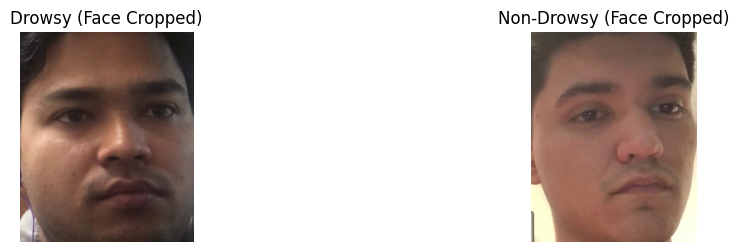

In [ ]:
plt.figure(figsize=(12, 6))
for i, class_name in enumerate(classes):

    class_folder = os.path.join(base_path, class_name)
    image_name = random.choice(os.listdir(class_folder))
    image_path = os.path.join(class_folder, image_name)

    cropped_face = detect_and_crop_face(image_path)

    plt.subplot(2, 2, i+1)

    if cropped_face is not None:
        plt.imshow(cropped_face)
        plt.title(f"{class_name} (Face Cropped)")
    else:
        plt.title(f"{class_name} (No Face Detected)")

    plt.axis("off")

plt.show()

# Estimating Face Detection Success Rate through Random Sampling

In [ ]:
# ----------------------------------------------------------
# Estimate face detection success rate using random sampling
# ----------------------------------------------------------
sample_size = 100  # statistically sufficient for estimation

all_image_paths = []

for class_name in classes:
    class_folder = os.path.join(data_path, class_name)

    for file in os.listdir(class_folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            all_image_paths.append(os.path.join(class_folder, file))

# Randomly sample images
sampled_images = random.sample(all_image_paths, min(sample_size, len(all_image_paths)))

faces_detected = 0

for image_path in sampled_images:
    face = detect_and_crop_face(image_path)
    if face is not None:
        faces_detected += 1

detection_rate = (faces_detected / len(sampled_images)) * 100

print("Sample size:", len(sampled_images))
print("Faces detected:", faces_detected)
print("Estimated detection rate:", round(detection_rate, 2), "%")

Sample size: 100
Faces detected: 100
Estimated detection rate: 100.0 %


# Verifying Dataset Path and Detecting Available Classes

In [ ]:
if not os.path.exists(base_path):
    raise ValueError("Base path does not exist. Check your path.")
print("Using dataset path:", base_path)
classes = [
    folder for folder in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, folder))
]
print("\nDetected classes:")
for c in classes:
    print("-", c)

# Face Detection, Padding, and Resizing for Standardized Input

In [ ]:
# ----------------------------------------------------------
# Face detection + padding + resize
# ----------------------------------------------------------
def detect_crop_resize(image_path, size=224, padding=0.2):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']
    x, y = max(0, x), max(0, y)

    pad_w = int(w * padding)
    pad_h = int(h * padding)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(img_rgb.shape[1], x + w + pad_w)
    y2 = min(img_rgb.shape[0], y + h + pad_h)

    face = img_rgb[y1:y2, x1:x2]

    if face.size == 0:
        return None

    face_resized = cv2.resize(face, (size, size))

    return face_resized

# Setting Up Directory for Processed Dataset Storage

In [ ]:
processed_root = os.path.join(
    os.path.dirname(base_path),
    "DPDDataset_face_224"
)

os.makedirs(processed_root, exist_ok=True)

print("Processed dataset will be saved to:")
print(processed_root)

In [ ]:
print("base_path:")
print(base_path)

print("\nFolders inside base_path:")
print(os.listdir(base_path))

# Batch Processing of Images: Face Detection, Cropping, and Saving

In [ ]:

failed_images = []

for class_name in classes:

    raw_class_path = os.path.join(base_path, class_name)
    processed_class_path = os.path.join(processed_root, class_name)

    os.makedirs(processed_class_path, exist_ok=True)

    image_files = [
        f for f in os.listdir(raw_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"\nProcessing class: {class_name}")

    for file in tqdm(image_files):

        input_path = os.path.join(raw_class_path, file)
        output_path = os.path.join(processed_class_path, file)

        if os.path.exists(output_path):
            continue

        try:
            # Detect, crop and resize face (assuming detect_crop_resize is implemented)
            face = detect_crop_resize(input_path)

            if face is not None:
                face_resized = cv2.resize(face, (224, 224))

                # For model
                face_expanded = np.expand_dims(face_resized.astype(np.float32), axis=0)
                face_preprocessed = preprocess_input(face_expanded)

                # For saving
                cv2.imwrite(output_path, face_resized)
            else:
                failed_images.append(input_path)

        except Exception as e:
            failed_images.append(input_path)

print("\nProcessing complete.")
print("Total failed detections:", len(failed_images))


Processing class: Drowsy


100%|██████████| 19416/19416 [1:53:53<00:00,  2.84it/s]  



Processing class: Non-Drowsy


100%|██████████| 15389/15389 [1:22:03<00:00,  3.13it/s]


Processing complete.
Total failed detections: 19


# Verifying Processed Dataset Integrity: Image Count Validation

In [13]:
# ----------------------------------------------------------
# Verify processed dataset integrity
# ----------------------------------------------------------

for class_name in classes:

    raw_class_path = os.path.join(base_path, class_name)
    processed_class_path = os.path.join(processed_root, class_name)

    raw_count = len([
        f for f in os.listdir(raw_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    processed_count = len(os.listdir(processed_class_path))

    print(f"{class_name}:")
    print("  Raw images:", raw_count)
    print("  Processed images:", processed_count)
    print("  Lost images:", raw_count - processed_count)
    print()

Drowsy:
  Raw images: 19416
  Processed images: 19402
  Lost images: 14

Non-Drowsy:
  Raw images: 15389
  Processed images: 15384
  Lost images: 5



# Analyzing Image Size Uniformity in the Processed Dataset

In [ ]:
sizes = set()

for class_name in classes:
    class_folder = os.path.join(processed_root, class_name)
    for img in os.listdir(class_folder)[:100]:  # sample 100
        img_path = os.path.join(class_folder, img)
        image = cv2.imread(img_path)
        sizes.add(image.shape[:2])

print("Unique image sizes found:", sizes)

Unique image sizes found: {(224, 224)}


# Inspecting Sample Filenames per Class for Dataset Verification

In [ ]:
# Inspect sample filenames per class

for class_name in classes:
    class_folder = os.path.join(processed_root, class_name)
    sample_files = os.listdir(class_folder)[:20]
    print(f"\nSample filenames from {class_name}:")
    for f in sample_files:
        print(f)


Sample filenames from Drowsy:
frame_Fold1_part1_01_10020.jpg
frame_Fold1_part1_01_10050.jpg
frame_Fold1_part1_01_10080.jpg
frame_Fold1_part1_01_10110.jpg
frame_Fold1_part1_01_10140.jpg
frame_Fold1_part1_01_10170.jpg
frame_Fold1_part1_01_1020.jpg
frame_Fold1_part1_01_10200.jpg
frame_Fold1_part1_01_10230.jpg
frame_Fold1_part1_01_10260.jpg
frame_Fold1_part1_01_10290.jpg
frame_Fold1_part1_01_10320.jpg
frame_Fold1_part1_01_10350.jpg
frame_Fold1_part1_01_10380.jpg
frame_Fold1_part1_01_10410.jpg
frame_Fold1_part1_01_10440.jpg
frame_Fold1_part1_01_10470.jpg
frame_Fold1_part1_01_1050.jpg
frame_Fold1_part1_01_10500.jpg
frame_Fold1_part1_01_10530.jpg

Sample filenames from Non-Drowsy:
frame_Fold1_part1_01_10020.jpg
frame_Fold1_part1_01_10050.jpg
frame_Fold1_part1_01_10080.jpg
frame_Fold1_part1_01_10110.jpg
frame_Fold1_part1_01_10140.jpg
frame_Fold1_part1_01_10170.jpg
frame_Fold1_part1_01_1020.jpg
frame_Fold1_part1_01_10200.jpg
frame_Fold1_part1_01_10230.jpg
frame_Fold1_part1_01_10260.jpg
frame_F

# Visualizing Random Processed Face Samples for Quality Assurance

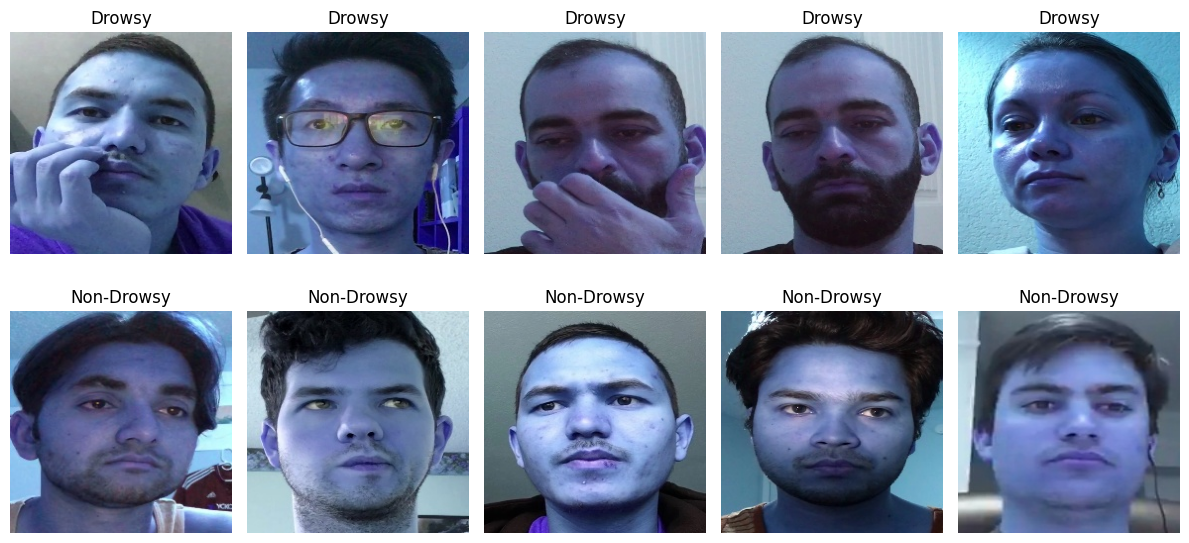

In [ ]:
# ----------------------------------------------------------
# Visualize random processed face samples (robust version)
# ----------------------------------------------------------



plt.figure(figsize=(12, 6))
plot_index = 1

for class_name in classes:

    class_folder = os.path.join(processed_root, class_name)

    # Filter only image files
    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Ensure we don't sample more than available
    sample_count = min(5, len(image_files))
    random_images = random.sample(image_files, sample_count)

    for img_name in random_images:
        img_path = os.path.join(class_folder, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue  # skip unreadable images

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 5, plot_index)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

# Creating Train, Validation, and Test Split Structure

In [ ]:
# ----------------------------------------------------------
# Create train / val / test split structure
# ----------------------------------------------------------
split_root = processed_root + "_split"

train_dir = os.path.join(split_root, "train")
val_dir   = os.path.join(split_root, "val")
test_dir  = os.path.join(split_root, "test")

for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)
    for class_name in classes:
        os.makedirs(os.path.join(split, class_name), exist_ok=True)

print("Split folders created at:")
print(split_root)

# Stratified Dataset Split for Training, Validation, and Testing

In [22]:
# ----------------------------------------------------------
# Stratified split (70 / 15 / 15)
# ----------------------------------------------------------

for class_name in classes:

    class_folder = os.path.join(processed_root, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # First split: Train (70%) and Temp (30%)
    train_files, temp_files = train_test_split(
        image_files,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # Second split: Validation (15%) and Test (15%)
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    # Copy files
    for file in train_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(train_dir, class_name, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(val_dir, class_name, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(test_dir, class_name, file)
        )

print("Dataset split completed.")

Dataset split completed.


# Verifying Dataset Split Distribution

In [23]:
# ----------------------------------------------------------
# Verify split distribution
# ----------------------------------------------------------

for split_name, split_path in {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}.items():

    print(f"\n{split_name} Set:")

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        count = len(os.listdir(class_path))
        print(f"  {class_name}: {count}")


Train Set:
  Drowsy: 13581
  Non-Drowsy: 10768

Validation Set:
  Drowsy: 2910
  Non-Drowsy: 2308

Test Set:
  Drowsy: 2911
  Non-Drowsy: 2308


# Defining Dataset Paths for Train, Validation, and Test Sets

In [ ]:
# ----------------------------------------------------------
# Define dataset paths
# ----------------------------------------------------------

train_path = os.path.join(split_root, "train")
val_path   = os.path.join(split_root, "val")
test_path  = os.path.join(split_root, "test")

print("Train path:", train_path)
print("Validation path:", val_path)
print("Test path:", test_path)

# Creating Data Generators for Model Training, Validation, and Testing

In [26]:
# ----------------------------------------------------------
# Data Generators
# ----------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 24349 files belonging to 2 classes.
Found 5218 files belonging to 2 classes.
Found 5219 files belonging to 2 classes.
Classes: ['Drowsy', 'Non-Drowsy']


# MobileNetV2 Preprocessing: Normalization and Performance Optimization

In [27]:
# ----------------------------------------------------------
# Preprocessing for MobileNetV2 (Corrected)
# ----------------------------------------------------------

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# Building MobileNetV2 Transfer Learning Model with L2 Regularization

In [ ]:

# Build MobileNetV2 Transfer Learning Model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the backbone of MobileNetV2 to avoid updating weights during training
base_model.trainable = False

# Define the new model with L2 regularization
model = models.Sequential([
    base_model,  # Base model (MobileNetV2 without top layers)
    layers.GlobalAveragePooling2D(),  # Pooling layer
    
    # Dense layer with L2 regularization
    layers.Dense(256, activation="relu", 
                 kernel_regularizer=regularizers.l2(0.01)),  # L2 regularization with lambda = 0.01
    layers.BatchNormalization(),  # Batch normalization for stability
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    
    # Output layer for classification (2 classes)
    layers.Dense(2, activation="softmax")  # Softmax for multi-class classification
])

# Print the model summary to check the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,458 (9.87 MB)

 Trainable params: 328,962 (1.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# Compiling and Training MobileNetV2 Model with Callbacks

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9047 - loss: 3.4716

761/761 ━━━━━━━━━━━━━━━━━━━━ 294s 386ms/step - accuracy: 0.9462 - loss: 2.8322 - val_accuracy: 0.9958 - val_loss: 1.8447 - learning_rate: 1.0000e-04
Epoch 2/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9864 - loss: 1.6162

761/761 ━━━━━━━━━━━━━━━━━━━━ 270s 354ms/step - accuracy: 0.9882 - loss: 1.3980 - val_accuracy: 0.9971 - val_loss: 1.0088 - learning_rate: 1.0000e-04
Epoch 3/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9927 - loss: 0.9024

761/761 ━━━━━━━━━━━━━━━━━━━━ 265s 348ms/step - accuracy: 0.9929 - loss: 0.7941 - val_accuracy: 0.9985 - val_loss: 0.5957 - learning_rate: 1.0000e-04
Epoch 4/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9934 - loss: 0.5423

761/761 ━━━━━━━━━━━━━━━━━━━━ 288s 378ms/step - accuracy: 0.9946 - loss: 0.4826 - val_accuracy: 0.9941 - val_loss: 0.3840 - learning_rate: 1.0000e-04
Epoch 5/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9944 - loss: 0.3463

...

761/761 ━━━━━━━━━━━━━━━━━━━━ 280s 368ms/step - accuracy: 0.9960 - loss: 0.0683 - val_accuracy: 0.9983 - val_loss: 0.0542 - learning_rate: 1.0000e-04
Epoch 12/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 288s 378ms/step - accuracy: 0.9943 - loss: 0.0653 - val_accuracy: 0.9975 - val_loss: 0.0543 - learning_rate: 1.0000e-04
Epoch 13/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 284s 373ms/step - accuracy: 0.9961 - loss: 0.0551 - val_accuracy: 0.9944 - val_loss: 0.0586 - learning_rate: 1.0000e-04
Epoch 14/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9938 - loss: 0.0545

761/761 ━━━━━━━━━━━━━━━━━━━━ 289s 380ms/step - accuracy: 0.9940 - loss: 0.0549 - val_accuracy: 0.9987 - val_loss: 0.0427 - learning_rate: 1.0000e-04
Epoch 15/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9941 - loss: 0.0532

761/761 ━━━━━━━━━━━━━━━━━━━━ 290s 380ms/step - accuracy: 0.9943 - loss: 0.0523 - val_accuracy: 0.9973 - val_loss: 0.0419 - learning_rate: 1.0000e-04
Epoch 16/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 304s 399ms/step - accuracy: 0.9956 - loss: 0.0460 - val_accuracy: 0.9964 - val_loss: 0.0425 - learning_rate: 1.0000e-04
Epoch 17/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9950 - loss: 0.0465

761/761 ━━━━━━━━━━━━━━━━━━━━ 287s 377ms/step - accuracy: 0.9954 - loss: 0.0450 - val_accuracy: 0.9985 - val_loss: 0.0355 - learning_rate: 1.0000e-04
Epoch 18/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 299s 393ms/step - accuracy: 0.9938 - loss: 0.0481 - val_accuracy: 0.9921 - val_loss: 0.0542 - learning_rate: 1.0000e-04
Epoch 19/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 287s 377ms/step - accuracy: 0.9953 - loss: 0.0440 - val_accuracy: 0.9967 - val_loss: 0.0396 - learning_rate: 1.0000e-04
Epoch 20/20
761/761 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9934 - loss: 0.0487

761/761 ━━━━━━━━━━━━━━━━━━━━ 275s 362ms/step - accuracy: 0.9939 - loss: 0.0472 - val_accuracy: 0.9987 - val_loss: 0.0349 - learning_rate: 1.0000e-04


# Saving the Model and Training History

In [ ]:
# import pickle
# with open("/content/drive/MyDrive/history.pkl", "wb") as f:
#     pickle.dump(history.history, f)
    

# model.save("/content/drive/MyDrive/drowsiness_model_v1.keras")
save_dir = r"C:\tausif\models"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "drowsiness_model_MobileNetV2.keras"))
save_dir = r"C:\tausif\models"
os.makedirs(save_dir, exist_ok=True)

history_path = os.path.join(save_dir, "history.pkl")

with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved successfully.")

Training history saved successfully.


# Evaluating Model on Test Dataset

In [34]:
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), tf.one_hot(y, depth=2))
).prefetch(AUTOTUNE)

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 325ms/step - accuracy: 0.5578 - loss: 5.2227
Test Accuracy: 0.5577697157859802
Test Loss: 5.222691059112549


# Visualizing Model Training and Validation Performance

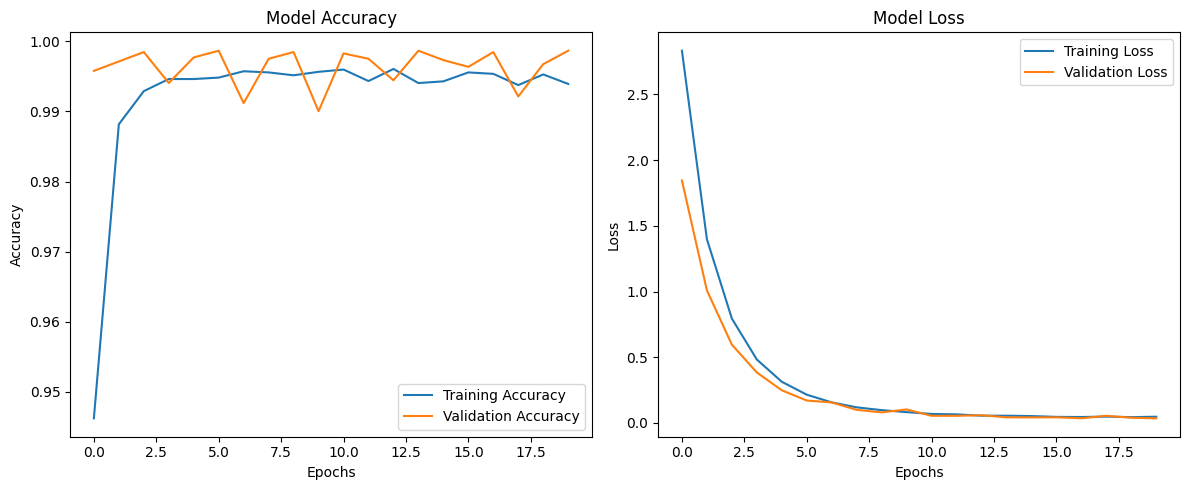

In [ ]:


# Plot the accuracy and loss curves
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Training and Evaluating Multiple Models: VGG16, VGG19, Xception, InceptionV3, EfficientNetB0

In [ ]:
# Define save directory
save_dir = r"C:\tausif\models" 
os.makedirs(save_dir, exist_ok=True) 

# Define a dictionary for models (excluding MobileNetV2 and ResNet50)
models_dict = {
    "VGG16": VGG16,
    "VGG19": VGG19,
    "Xception": Xception,
    "InceptionV3": InceptionV3,
    "EfficientNetB0": EfficientNetB0
}

# Prepare for storing results
results = {}

# ----------------------------------------
# Define Data Augmentation
# ----------------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Apply data augmentation to training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).prefetch(tf.data.AUTOTUNE)

# ----------------------------------------
# Function to Create and Train Models
# ----------------------------------------
def create_and_train_model(base_model_fn, model_name, train_ds, val_ds, test_ds):
    # Load the base model (without the top layers)
    base_model = base_model_fn(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    base_model.trainable = False  # Freeze the base model initially

    # Build the model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(0.05)),
        layers.BatchNormalization(),
        layers.Dropout(0.7),  # Increase dropout to prevent overfitting
        layers.Dense(2, activation="softmax")
    ])

    # Unfreeze the top layers of the model for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-4]:  # Unfreeze the top layers
        layer.trainable = False

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                  loss="categorical_crossentropy", metrics=["accuracy"])

    # Define callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=1e-6)
    ]
    
    # Train the model
    history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

    # SAVE MODEL RIGHT AFTER TRAINING (ONLY ADDITION)
    model_path = os.path.join(save_dir, f"drowsiness_model_{model_name}.keras")
    model.save(model_path)
    print(f"Saved {model_name} at: {model_path}")

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(test_ds)
    
    # Store results for later comparison
    results[model_name] = {"test_accuracy": test_accuracy, "history": history}

    print(f"{model_name} Test Accuracy: {test_accuracy}")
    return model_name, test_accuracy

# ----------------------------------------
# Loop Through the Models
# ----------------------------------------

# Iterate through the models and train each one
for model_name, base_model_fn in models_dict.items():
    print(f"Training {model_name}...")
    create_and_train_model(base_model_fn, model_name, train_ds, val_ds, test_ds)

# ----------------------------------------
# Summary of Results
# ----------------------------------------
print("\nSummary of Model Test Accuracy:")
for model_name, result in results.items():
    print(f"{model_name}: {result['test_accuracy']:.4f}")

# Training and Evaluating VGG16 for Driver Drowsiness Detection with Augmentation

In [ ]:

# 2. Define data generators with preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical'  # Use 'binary' for binary classification
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Use 'binary' for binary classification
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Use 'binary' for binary classification
)

# 3. Load VGG16 model without top layers (so we can add our own)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model.trainable = False

# 4. Create the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Pooling layer
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.05)),  # Dense layer with regularization
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Dropout for regularization
    layers.Dense(train_generator.num_classes, activation='softmax')  # Output layer (change if binary classification)
])

# 5. Compile the model
model.compile(optimizer=Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy',  # Use 'binary_crossentropy' for binary classification
              metrics=['accuracy'])

# 6. Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=1e-6)
]

# 7. Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=5,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=callbacks
)

# 8. Evaluate the model on the test set
# 8. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=test_generator.samples // test_generator.batch_size
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")  

# 9. Save the trained model
save_dir = r"C:\tausif\models"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "drowsiness_model_VGG16.keras")
model.save(model_path)

print(f"Model saved at: {model_path}")
model.save('vgg16_trained_model.h5')

# Evaluating Fine-Tuned VGG16 Model on Test Data

In [ ]:


# 2. Define data generators with preprocessing and augmentation
test_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    preprocessing_function=preprocess_input  # Use VGG16 preprocessing
)

train_dir = r"C:\tausif\Data\DPDDataset_face_224_split\train"
val_dir = r"C:\tausif\Data\DPDDataset_face_224_split\val"
test_dir = r"C:\tausif\Data\DPDDataset_face_224_split\test"

# Define the test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Resize images to 224x224 for VGG16
    batch_size=32,
    class_mode='categorical'  # Assuming you are using multi-class classification
)

# 3. Load the fine-tuned VGG16 model from the specified path
model_path = r"C:\tausif\models\vgg16_trained_model_fineTuned.keras"
model = load_model(model_path)

# 4. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=test_generator.samples // test_generator.batch_size
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Found 5219 images belonging to 2 classes.
163/163 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.8447 - loss: 12.5901
Test Accuracy: 0.8447
Test Loss: 12.5901
